In [44]:
!pip install deepface pandas numpy tf-keras streamlit transformers scipy torch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 98.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 129.7 MB/s eta 0:00:00


In [2]:
pip freeze

absl-py==1.4.0
accelerate==1.13.0
access==1.1.10.post3
affine==2.4.0
aiofiles==24.1.0
aiohappyeyeballs==2.6.1
aiohttp==3.13.5
aiosignal==1.4.0
aiosqlite==0.22.1
alabaster==1.0.0
albucore==0.0.24
albumentations==2.0.8
ale-py==0.11.2
alembic==1.18.4
altair==5.5.0
annotated-doc==0.0.4
annotated-types==0.7.0
antlr4-python3-runtime==4.9.3
anyio==4.13.0
anywidget==0.9.21
apsw==3.53.0.0
apswutils==0.1.2
argon2-cffi==25.1.0
argon2-cffi-bindings==25.1.0
array_record==0.8.3
arrow==1.4.0
arviz==0.22.0
astropy==7.2.0
astropy-iers-data==0.2026.4.20.0.58.15
astunparse==1.6.3
atpublic==5.1
attrs==26.1.0
audioread==3.1.0
Authlib==1.6.11
autograd==1.8.0
babel==2.18.0
backcall==0.2.0
beartype==0.22.9
beautifulsoup4==4.13.5
betterproto==2.0.0b6
bigframes==2.39.0
bigquery-magics==0.14.0
bleach==6.3.0
blinker==1.9.0
blis==1.3.3
blobfile==3.2.0
blosc2==4.1.2
bokeh==3.8.2
Bottleneck==1.4.2
bqplot==0.12.45
branca==0.8.2
brotli==1.2.0
CacheControl==0.14.4
cachetools==6.2.6
catalogue==2.0.10
certifi==2026.4.22


In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
!pip install deepface tf-keras opencv-python

import numpy as np
from deepface import DeepFace
import os

def extrair_dados_faciais(img_path):
    """
    Analisa uma imagem para extrair raça e gênero usando DeepFace.
    """
    try:
        # Executa a análise facial
        results = DeepFace.analyze(
            img_path = img_path,
            actions = ['gender', 'race'],
            detector_backend = 'retinaface',
            enforce_detection = True,
            silent = True
        )

        # DeepFace retorna uma lista (caso haja múltiplos rostos, pegamos o primeiro)
        res = results[0]

        return {
            'raca_dominante': res['dominant_race'],
            'confianca_raca': res['race'][res['dominant_race']],
            'genero_dominante': res['dominant_gender'],
            'confianca_genero': res['gender'][res['dominant_gender']]
        }

    except Exception as e:
        # Retorna np.nan se houver erro na detecção ou processamento
        return {
            'raca_dominante': np.nan,
            'confianca_raca': np.nan,
            'genero_dominante': np.nan,
            'confianca_genero': np.nan
        }

26-05-17 15:48:12 - Directory /root/.deepface has been created
26-05-17 15:48:12 - Directory /root/.deepface/weights has been created


### Exemplo de Uso
O código abaixo demonstra como aplicar a função nas subpastas.

In [11]:
import pandas as pd
import os

base_path = "/content/drive/MyDrive/Estudo UNAL/Images Generated by IA"
subpastas_alvo = ["Inclusive Prompts", "Neutral Prompts"]
dados_finais = []

for sub in subpastas_alvo:
    caminho_raiz = os.path.join(base_path, sub)
    if os.path.exists(caminho_raiz):
        print(f"Explorando pasta: {sub}")
        # os.walk percorre todas as subpastas recursivamente
        for root, dirs, files in os.walk(caminho_raiz):
            for arquivo in files:
                if arquivo.lower().endswith(('.png', '.jpg', '.jpeg')):
                    caminho_img = os.path.join(root, arquivo)

                    # Chamada da função de análise
                    resultado = extrair_dados_faciais(caminho_img)

                    # Adicionando metadados
                    resultado['arquivo'] = arquivo
                    resultado['categoria'] = sub
                    resultado['origem'] = os.path.basename(root) # Nome da subpasta (ex: Midjourney)
                    dados_finais.append(resultado)
    else:
        print(f"Aviso: Caminho não encontrado: {caminho_raiz}")

df_resultados = pd.DataFrame(dados_finais)
if not df_resultados.empty:
    print(f"Total de imagens processadas: {len(df_resultados)}")
    display(df_resultados.head())
else:
    print("Nenhuma imagem encontrada mesmo após a busca recursiva.")

Explorando pasta: Inclusive Prompts
Explorando pasta: Neutral Prompts
Total de imagens processadas: 64


,raca_dominante,confianca_raca,genero_dominante,confianca_genero,arquivo,categoria,origem
0,latino hispanic,31.166523,Man,99.989876,Kauandugi_Students_of_diverse_backgrounds_stud...,Inclusive Prompts,Inclusive prompt 2
1,white,99.600975,Woman,97.365311,Kauandugi_A_diverse_group_of_university_studen...,Inclusive Prompts,Inclusive prompt 1
2,middle eastern,49.847622,Man,99.665276,Kauandugi_A_diverse_group_of_students_walking_...,Inclusive Prompts,Inclusive prompt 4
3,white,88.383530,Man,99.871704,Kauandugi_Students_playing_futsal_on_a_univers...,Inclusive Prompts,Inclusive prompt 3
4,middle eastern,42.808456,Man,86.664810,Kauandugi_A_group_of_students_relaxing_and_cha...,Inclusive Prompts,Inclusive prompt 7


In [12]:
# Caminho atualizado com base na estrutura real verificada no seu Drive
caminho_teste = "/content/drive/MyDrive/Estudo UNAL/Images Generated by IA/Inclusive Prompts/Midjourney/Inclusive prompt 2/Kauandugi_Students_of_diverse_backgrounds_studying_together_a_98a7dfd5-3d30-446b-a169-f8a2008350ca_0.png"

# Chamando a função para testar um arquivo existente
resultado = extrair_dados_faciais(caminho_teste)
print("Resultado do teste individual:")
print(resultado)

Resultado do teste individual:
{'raca_dominante': 'latino hispanic', 'confianca_raca': np.float32(31.166523), 'genero_dominante': 'Man', 'confianca_genero': np.float32(99.989876)}


In [14]:
import os
# Listando os arquivos dentro da subpasta para verificar as extensões
test_sub = "Inclusive Prompts"
test_path = os.path.join(base_path, test_sub)
if os.path.exists(test_path):
    print(f"Arquivos em {test_sub}:")
    print(os.listdir(test_path)[:10]) # Mostra os primeiros 10 arquivos
else:
    print(f"Caminho não encontrado: {test_path}")

Arquivos em Inclusive Prompts:
['Midjourney', 'DALL-E', 'Whisk', 'Gemini (NanoBanana)']


In [15]:
import os
# Verificando se o diretório base existe e listando seu conteúdo
base_path = "/content/drive/MyDrive/Estudo UNAL/Images Generated by IA"
if os.path.exists(base_path):
    print(f"Conteúdo de {base_path}:")
    print(os.listdir(base_path))
else:
    print(f"ERRO: O caminho {base_path} não foi encontrado.")

Conteúdo de /content/drive/MyDrive/Estudo UNAL/Images Generated by IA:
['Neutral Prompts.txt', 'Inclusive promtps.txt', 'Inclusive Prompts', 'Neutral Prompts']


In [16]:
import os

base_path = "/content/drive/MyDrive/Estudo UNAL/Images Generated by IA"
subpastas_alvo = ["Inclusive Prompts", "Neutral Prompts"]

for sub in subpastas_alvo:
    caminho_raiz = os.path.join(base_path, sub)
    if os.path.exists(caminho_raiz):
        print(f"\n--- Conteúdo de: {sub} ---")
        for root, dirs, files in os.walk(caminho_raiz):
            nivel = root.replace(caminho_raiz, '').count(os.sep)
            indentacao = ' ' * 4 * (nivel)
            print(f"{indentacao}[{os.path.basename(root)}/]")
            sub_indentacao = ' ' * 4 * (nivel + 1)
            # Lista apenas os 5 primeiros arquivos de cada subpasta para não poluir o log
            for f in files[:5]:
                print(f"{sub_indentacao}{f}")
            if len(files) > 5:
                print(f"{sub_indentacao}... ({len(files) - 5} mais arquivos)")
    else:
        print(f"Caminho não encontrado: {caminho_raiz}")


--- Conteúdo de: Inclusive Prompts ---
[Inclusive Prompts/]
    [Midjourney/]
        [Inclusive prompt 2/]
            Kauandugi_Students_of_diverse_backgrounds_studying_together_a_98a7dfd5-3d30-446b-a169-f8a2008350ca_0.png
        [Inclusive prompt 1/]
            Kauandugi_A_diverse_group_of_university_students_attending_a__d7a70fb4-bb0f-4796-ad34-577a472b7502_2.png
        [Inclusive prompt 4/]
            Kauandugi_A_diverse_group_of_students_walking_and_talking_on__4d39e928-913c-4fd6-b1c7-941b936f7d0d_2.png
        [Inclusive prompt 3/]
            Kauandugi_Students_playing_futsal_on_a_university_indoor_cour_9f2c7c1b-f4c2-4cd6-ad9d-d908732c337b_3.png
        [Inclusive prompt 7/]
            Kauandugi_A_group_of_students_relaxing_and_chatting_in_a_camp_02fe41de-7f94-489d-b6b2-b3abeac4d486_1.png
        [Inclusive prompt 6/]
            Kauandugi_Students_participating_in_a_university_cultural_fai_e6f3e656-557f-4125-8e90-8be1441c742e_2.png
        [Inclusive prompt 5/]
         

In [18]:
import os
import pandas as pd

def processar_diretorio(diretorio_base, filtrar_categorias=True):
    """
    Percorre o diretório base. Se filtrar_categorias for True, busca especificamente
    pelas subpastas 'Inclusive Prompts' e 'Neutral Prompts'. Caso contrário,
    processa tudo que encontrar no caminho fornecido.
    """
    if filtrar_categorias:
        subpastas_alvo = ["Inclusive Prompts", "Neutral Prompts"]
    else:
        # Se não estiver filtrando, trata o diretório base como a própria raiz de busca
        subpastas_alvo = [""]

    dados_finais = []

    for sub in subpastas_alvo:
        caminho_raiz = os.path.join(diretorio_base, sub)

        if not os.path.exists(caminho_raiz):
            if sub: # Só avisa se estávamos procurando uma subpasta específica
                print(f"Aviso: Caminho não encontrado: {caminho_raiz}")
            continue

        print(f"Processando caminho: {caminho_raiz}...")

        for root, dirs, files in os.walk(caminho_raiz):
            for arquivo in files:
                if arquivo.lower().endswith(('.png', '.jpg', '.jpeg')):
                    caminho_img = os.path.join(root, arquivo)

                    resultado = extrair_dados_faciais(caminho_img)

                    dados_finais.append({
                        'nome_arquivo': arquivo,
                        'raca_dominante': resultado['raca_dominante'],
                        'confianca_raca': resultado['confianca_raca'],
                        'genero_dominante': resultado['genero_dominante'],
                        'confianca_genero': resultado['confianca_genero']
                    })

    df = pd.DataFrame(dados_finais)
    return df

In [19]:
# Exemplo de execução da função
diretorio_ia = "/content/drive/MyDrive/Estudo UNAL/Images Generated by IA"
df_resultados_ia = processar_diretorio(diretorio_ia)

# Exibindo os resultados
print(f"\nProcessamento concluído. Total de imagens: {len(df_resultados_ia)}")
display(df_resultados_ia.head())

Processando caminho: /content/drive/MyDrive/Estudo UNAL/Images Generated by IA/Inclusive Prompts...
Processando caminho: /content/drive/MyDrive/Estudo UNAL/Images Generated by IA/Neutral Prompts...

Processamento concluído. Total de imagens: 64


,nome_arquivo,raca_dominante,confianca_raca,genero_dominante,confianca_genero
0,Kauandugi_Students_of_diverse_backgrounds_stud...,latino hispanic,31.166523,Man,99.989876
1,Kauandugi_A_diverse_group_of_university_studen...,white,99.600975,Woman,97.365311
2,Kauandugi_A_diverse_group_of_students_walking_...,middle eastern,49.847622,Man,99.665276
3,Kauandugi_Students_playing_futsal_on_a_univers...,white,88.383530,Man,99.871704
4,Kauandugi_A_group_of_students_relaxing_and_cha...,middle eastern,42.808456,Man,86.664810


In [20]:
# Para processar as 64 imagens originais, usamos o caminho base que contém as categorias
caminho_base = "/content/drive/MyDrive/Estudo UNAL/Images Generated by IA"

# Chamando a função para o diretório raiz do projeto
df_resultados = processar_diretorio(caminho_base, filtrar_categorias=True)

# Visualizando os resultados
print(f"\nTotal de imagens processadas: {len(df_resultados)}")
display(df_resultados.head())

Processando caminho: /content/drive/MyDrive/Estudo UNAL/Images Generated by IA/Inclusive Prompts...
Processando caminho: /content/drive/MyDrive/Estudo UNAL/Images Generated by IA/Neutral Prompts...

Total de imagens processadas: 64


,nome_arquivo,raca_dominante,confianca_raca,genero_dominante,confianca_genero
0,Kauandugi_Students_of_diverse_backgrounds_stud...,latino hispanic,31.166523,Man,99.989876
1,Kauandugi_A_diverse_group_of_university_studen...,white,99.600975,Woman,97.365311
2,Kauandugi_A_diverse_group_of_students_walking_...,middle eastern,49.847622,Man,99.665276
3,Kauandugi_Students_playing_futsal_on_a_univers...,white,88.383530,Man,99.871704
4,Kauandugi_A_group_of_students_relaxing_and_cha...,middle eastern,42.808456,Man,86.664810


In [32]:
import torch
from PIL import Image
from transformers import CLIPProcessor, CLIPModel
import numpy as np

def avaliar_similaridade_clip_otimizado(caminho_imagem, textos_ancora, model, processor):
    """
    Avalia a similaridade semântica usando uma instância do CLIP já carregada na memória.
    """
    try:
        imagem = Image.open(caminho_imagem).convert("RGB")
        inputs = processor(text=textos_ancora, images=imagem, return_tensors="pt", padding=True)
        with torch.no_grad():
            outputs = model(**inputs)
        logits_per_image = outputs.logits_per_image[0].cpu().numpy()
        return {texto: float(escore) for texto, escore in zip(textos_ancora, logits_per_image)}
    except Exception as e:
        print(f"  [!] Erro no CLIP ao processar imagem: {e}")
        return {texto: np.nan for texto in textos_ancora}

def avaliar_similaridade_clip(caminho_imagem, textos_ancora):
    """
    Função de conveniência que carrega o modelo sob demanda (menos eficiente para loops longos).
    """
    model_id = "openai/clip-vit-base-patch32"
    processor = CLIPProcessor.from_pretrained(model_id)
    model = CLIPModel.from_pretrained(model_id)
    return avaliar_similaridade_clip_otimizado(caminho_imagem, textos_ancora, model, processor)

In [23]:
!pip install transformers torch Pillow

In [36]:
# Definindo as âncoras semânticas do experimento
ancoras_culturais = [
    "A typical Latin American university campus",
    "A typical European university campus",
    "A typical North American university campus"
]

# Usando a imagem de teste já mapeada anteriormente
caminho_teste = "/content/drive/MyDrive/Estudo UNAL/Images Generated by IA/Inclusive Prompts/Midjourney/Inclusive prompt 2/Kauandugi_Students_of_diverse_backgrounds_studying_together_a_98a7dfd5-3d30-446b-a169-f8a2008350ca_0.png"

# Executando o módulo CLIP (agora definido)
resultado_semantico = avaliar_similaridade_clip(caminho_teste, ancoras_culturais)

print("Escores de Similaridade Semântica (CLIP):")
for texto, escore in resultado_semantico.items():
    print(f"'{texto}': {escore:.4f}")

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Escores de Similaridade Semântica (CLIP):
'A typical Latin American university campus': 19.7609
'A typical European university campus': 19.8579
'A typical North American university campus': 19.5870


In [26]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [37]:
import os

caminho_teste = "/content/drive/MyDrive/Estudo UNAL/Images Generated by IA/Inclusive Prompts/Midjourney/Inclusive prompt 2/Kauandugi_Students_of_diverse_backgrounds_studying_together_a_98a7dfd5-3d30-446b-a169-f8a2008350ca_0.png"

# Verificação de segurança antes de rodar a IA
if os.path.exists(caminho_teste):
    print("A imagem foi encontrada! Iniciando o CLIP...\n")
    resultado_semantico = avaliar_similaridade_clip(caminho_teste, ancoras_culturais)
    for texto, escore in resultado_semantico.items():
        print(f"'{texto}': {escore:.4f}")
else:
    print("O caminho ainda está incorreto ou o Drive não está montado.")

A imagem foi encontrada! Iniciando o CLIP...



Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


'A typical Latin American university campus': 19.7609
'A typical European university campus': 19.8579
'A typical North American university campus': 19.5870


In [39]:
import os
import pandas as pd
import numpy as np

def executar_auditoria_completa(caminho_pasta, textos_ancora):
    """
    Percorre um diretório, realiza análise facial e de similaridade CLIP,
    e exporta os resultados consolidados para CSV.
    """
    lista_resultados = []

    # Busca recursiva para garantir que encontramos as imagens nas subpastas
    arquivos_encontrados = []
    for root, dirs, files in os.walk(caminho_pasta):
        for f in files:
            if f.lower().endswith(('.png', '.jpg', '.jpeg')):
                arquivos_encontrados.append(os.path.join(root, f))

    if not arquivos_encontrados:
        print(f"Nenhuma imagem encontrada em: {caminho_pasta}")
        return pd.DataFrame()

    print(f"Iniciando auditoria de {len(arquivos_encontrados)} imagens...")

    # Carrega o modelo uma vez para ser eficiente
    model_id = "openai/clip-vit-base-patch32"
    processor = CLIPProcessor.from_pretrained(model_id)
    model = CLIPModel.from_pretrained(model_id)

    for caminho_img in arquivos_encontrados:
        nome_arquivo = os.path.basename(caminho_img)

        # Tenta extrair o tipo de prompt da estrutura de pastas
        partes = caminho_img.split(os.sep)
        tipo_prompt = "Desconhecido"
        if "Inclusive Prompts" in partes: tipo_prompt = "Inclusive Prompts"
        elif "Neutral Prompts" in partes: tipo_prompt = "Neutral Prompts"

        # 1. Extração de dados faciais (DeepFace)
        dados_faciais = extrair_dados_faciais(caminho_img)

        # 2. Avaliação de similaridade (CLIP) otimizada
        dados_clip = avaliar_similaridade_clip_otimizado(caminho_img, textos_ancora, model, processor)

        # Consolidar dados da linha
        registro = {
            'nome_arquivo': nome_arquivo,
            'tipo_prompt': tipo_prompt,
            'raca': dados_faciais['raca_dominante'],
            'conf_raca': dados_faciais['confianca_raca'],
            'genero': dados_faciais['genero_dominante'],
            'conf_genero': dados_faciais['confianca_genero']
        }

        registro.update(dados_clip)
        lista_resultados.append(registro)

    df_final = pd.DataFrame(lista_resultados)
    csv_path = "resultados_auditoria_tcc.csv"
    df_final.to_csv(csv_path, index=False, encoding='utf-8-sig')

    print(f"Auditoria concluída! Arquivo salvo como: {csv_path}")
    return df_final

In [40]:
import os
import pandas as pd

def executar_auditoria_completa_otimizada(caminho_raiz, textos_ancora):
    print("Iniciando o Pipeline de Auditoria...")

    # ======================================================
    # ETAPA 1: ALOCAÇÃO DE RECURSOS (Feito apenas 1 vez)
    # ======================================================
    print("-> Carregando pesos do CLIP na GPU (Isso levará alguns segundos)...")
    model_id = "openai/clip-vit-base-patch32"
    processor = CLIPProcessor.from_pretrained(model_id)
    model = CLIPModel.from_pretrained(model_id)
    print("-> CLIP carregado com sucesso! Iniciando processamento em lote...\n")

    resultados = []

    # ======================================================
    # ETAPA 2: VARREDURA RECURSIVA (Loop)
    # ======================================================
    for root, dirs, files in os.walk(caminho_raiz):
        for file in files:
            # Filtra apenas imagens
            if file.lower().endswith(('.png', '.jpg', '.jpeg')):
                caminho_completo = os.path.join(root, file)

                # Extração de Metadados (Tipo de Prompt e Modelo) baseada nas pastas
                partes_caminho = caminho_completo.split(os.sep)
                tipo_prompt = partes_caminho[-3] if len(partes_caminho) >= 3 else "Desconhecido"
                modelo_ia = partes_caminho[-2] if len(partes_caminho) >= 2 else "Desconhecido"

                print(f"Processando: [{modelo_ia}] {file}")

                # 1. Audita Demografia (DeepFace)
                # (Assumindo que a sua função 'extrair_dados_faciais' já está no notebook)
                dados_faciais = extrair_dados_faciais(caminho_completo)

                # 2. Audita Semântica Cultural (CLIP) - Passando os modelos instanciados!
                dados_clip = avaliar_similaridade_clip_otimizado(caminho_completo, textos_ancora, model, processor)

                # 3. Consolida os dados da iteração
                linha_resultado = {
                    'nome_arquivo': file,
                    'tipo_prompt': tipo_prompt,
                    'modelo_ia': modelo_ia,
                    'raca': dados_faciais.get('raca_dominante', np.nan),
                    'conf_raca': dados_faciais.get('confianca_raca', np.nan),
                    'genero': dados_faciais.get('genero_dominante', np.nan),
                    'conf_genero': dados_faciais.get('confianca_genero', np.nan)
                }

                # Mescla as colunas do CLIP com as colunas demográficas
                linha_resultado.update(dados_clip)
                resultados.append(linha_resultado)

    # ======================================================
    # ETAPA 3: EXPORTAÇÃO
    # ======================================================
    df_final = pd.DataFrame(resultados)
    caminho_saida = 'resultados_auditoria_tcc_v2.csv'
    df_final.to_csv(caminho_saida, index=False)

    print(f"\n✅ Concluído! Dados salvos com sucesso em: {caminho_saida}")
    return df_final

In [41]:
# Execução da Auditoria Completa
caminho_base_estudo = "/content/drive/MyDrive/Estudo UNAL/Images Generated by IA"

# Rodando o processo completo
df_final_auditoria = executar_auditoria_completa(caminho_base_estudo, ancoras_culturais)

# Visualização prévia do CSV gerado
display(df_final_auditoria.head())

Iniciando auditoria de 64 imagens...


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Auditoria concluída! Arquivo salvo como: resultados_auditoria_tcc.csv


,nome_arquivo,tipo_prompt,raca,conf_raca,genero,conf_genero,A typical Latin American university campus,A typical European university campus,A typical North American university campus
0,Kauandugi_Students_of_diverse_backgrounds_stud...,Inclusive Prompts,latino hispanic,31.166523,Man,99.989876,19.760897,19.857861,19.587004
1,Kauandugi_A_diverse_group_of_university_studen...,Inclusive Prompts,white,99.600975,Woman,97.365311,19.269300,19.497314,19.315832
2,Kauandugi_A_diverse_group_of_students_walking_...,Inclusive Prompts,middle eastern,49.847622,Man,99.665276,24.092264,26.263447,25.639593
3,Kauandugi_Students_playing_futsal_on_a_univers...,Inclusive Prompts,white,88.383530,Man,99.871704,19.498133,17.922268,18.365938
4,Kauandugi_A_group_of_students_relaxing_and_cha...,Inclusive Prompts,middle eastern,42.808456,Man,86.664810,25.399168,23.179964,25.894150


###Gerar os gráficos (Boxplots e Gráficos de Barras)

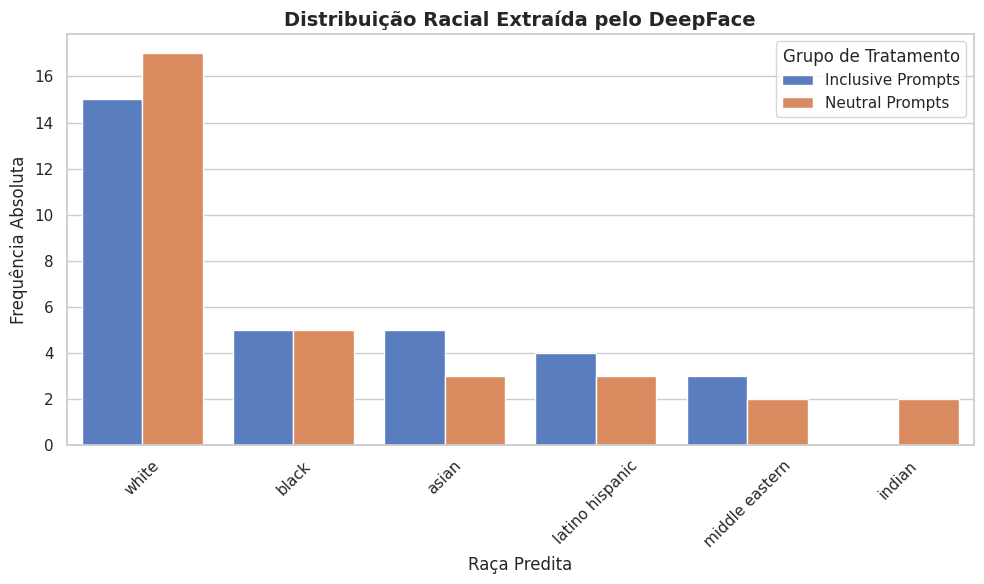

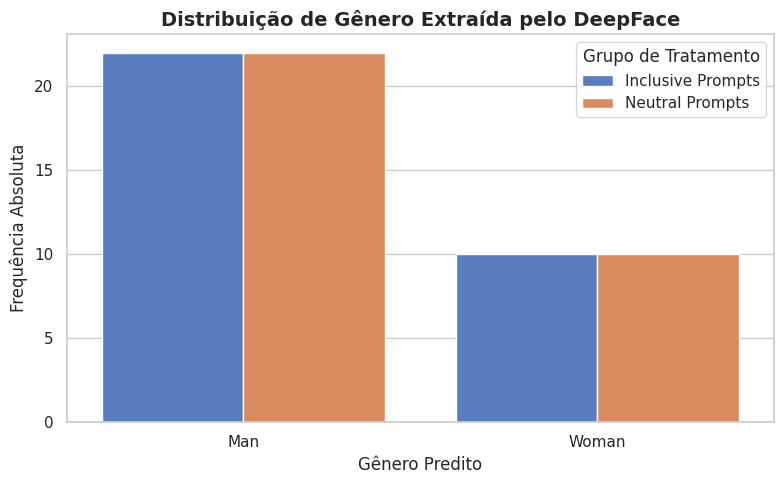

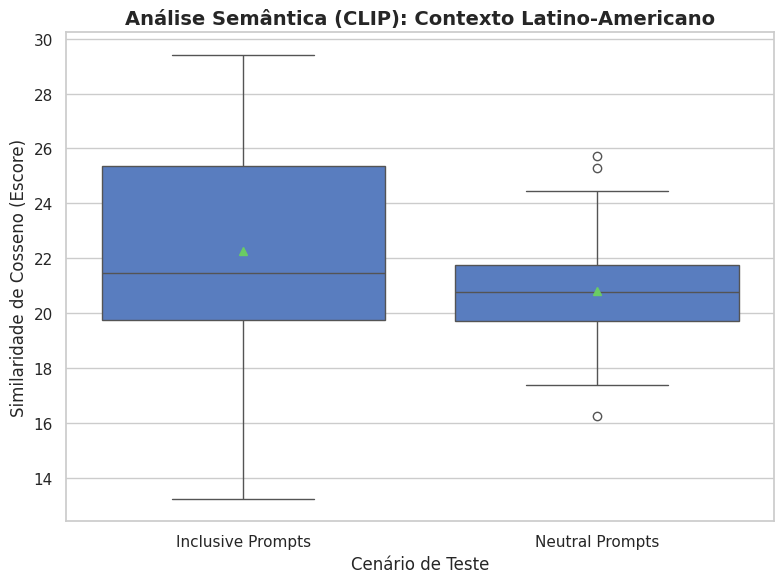


RELATÓRIO ESTATÍSTICO AUTOMATIZADO - BIAS AUDIT FW
Teste U de Mann-Whitney para o contexto Latino-Americano:
Estatística U: 624.0
P-Value: 0.13436 (Limiar alpha = 0.05)
=> Aceita H0: NÃO existe diferença significativa. O viés cultural eurocêntrico/genérico persiste mesmo com prompts inclusivos.


In [42]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu

# 1. Carregar o banco de dados
df = pd.read_csv('resultados_auditoria_tcc.csv')

# Definir estilo acadêmico dos gráficos
sns.set_theme(style="whitegrid", palette="muted")

# ==========================================
# GRÁFICO 1: DISTRIBUIÇÃO DEMOGRÁFICA (RAÇA)
# ==========================================
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='raca', hue='tipo_prompt',
              order=df['raca'].value_counts().index)
plt.title('Distribuição Racial Extraída pelo DeepFace', fontsize=14, fontweight='bold')
plt.xlabel('Raça Predita', fontsize=12)
plt.ylabel('Frequência Absoluta', fontsize=12)
plt.legend(title='Grupo de Tratamento')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('grafico_raca.png') # Salva a imagem para usar no LaTeX
plt.show()

# ==========================================
# GRÁFICO 2: DISTRIBUIÇÃO DE GÊNERO
# ==========================================
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='genero', hue='tipo_prompt')
plt.title('Distribuição de Gênero Extraída pelo DeepFace', fontsize=14, fontweight='bold')
plt.xlabel('Gênero Predito', fontsize=12)
plt.ylabel('Frequência Absoluta', fontsize=12)
plt.legend(title='Grupo de Tratamento')
plt.tight_layout()
plt.savefig('grafico_genero.png')
plt.show()

# ==========================================
# GRÁFICO 3 E ESTATÍSTICA: ANÁLISE SEMÂNTICA (CLIP)
# ==========================================
ancora_latina = 'A typical Latin American university campus'

plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='tipo_prompt', y=ancora_latina, showmeans=True)
plt.title('Análise Semântica (CLIP): Contexto Latino-Americano', fontsize=14, fontweight='bold')
plt.xlabel('Cenário de Teste', fontsize=12)
plt.ylabel('Similaridade de Cosseno (Escore)', fontsize=12)
plt.tight_layout()
plt.savefig('grafico_clip_latino.png')
plt.show()

# Executando o Teste U de Mann-Whitney
inclusivo = df[df['tipo_prompt'] == 'Inclusive Prompts'][ancora_latina].dropna()
neutro = df[df['tipo_prompt'] == 'Neutral Prompts'][ancora_latina].dropna()

stat, p_value = mannwhitneyu(inclusivo, neutro, alternative='two-sided')

print("\n" + "="*50)
print("RELATÓRIO ESTATÍSTICO AUTOMATIZADO - BIAS AUDIT FW")
print("="*50)
print(f"Teste U de Mann-Whitney para o contexto Latino-Americano:")
print(f"Estatística U: {stat}")
print(f"P-Value: {p_value:.5f} (Limiar alpha = 0.05)")
if p_value < 0.05:
    print("=> Rejeita H0: Existe diferença estatisticamente significativa na representação cultural.")
else:
    print("=> Aceita H0: NÃO existe diferença significativa. O viés cultural eurocêntrico/genérico persiste mesmo com prompts inclusivos.")

In [45]:
import streamlit as st
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu

# Configuração inicial da página
st.set_page_config(page_title="BiasAuditFW Dashboard", layout="wide")

# Título do App
st.title("🔍 BiasAuditFW: Auditoria de Viés em IA Generativa")
st.markdown("Dashboard interativo para análise de vieses demográficos e culturais em modelos de difusão texto-imagem.")

# 1. Carregar os dados com cache (para performance na web)
@st.cache_data
def load_data():
    return pd.read_csv('resultados_auditoria_tcc.csv')

df = load_data()

# ==========================================
# BARRA LATERAL (Filtros Interativos)
# ==========================================
st.sidebar.header("Filtros de Análise")
modelos_disponiveis = df['modelo_ia'].unique().tolist()
modelo_selecionado = st.sidebar.multiselect("Filtrar por Modelo de IA:", modelos_disponiveis, default=modelos_disponiveis)

# Aplicar filtro
df_filtrado = df[df['modelo_ia'].isin(modelo_selecionado)]

# ==========================================
# MÉTRICAS RÁPIDAS (KPIs)
# ==========================================
st.subheader("Visão Geral")
col1, col2, col3 = st.columns(3)
col1.metric(label="Imagens Analisadas", value=len(df_filtrado))
col2.metric(label="Rostos Brancos Detectados", value=len(df_filtrado[df_filtrado['raca'] == 'white']))
col3.metric(label="Rostos Masculinos Detectados", value=len(df_filtrado[df_filtrado['genero'] == 'Man']))

st.divider()

# ==========================================
# GRÁFICOS INTERATIVOS
# ==========================================
sns.set_theme(style="whitegrid", palette="muted")
colA, colB = st.columns(2)

with colA:
    st.subheader("Distribuição Racial")
    fig_raca, ax1 = plt.subplots(figsize=(6, 4))
    sns.countplot(data=df_filtrado, x='raca', hue='tipo_prompt', order=df_filtrado['raca'].value_counts().index, ax=ax1)
    plt.xticks(rotation=45)
    st.pyplot(fig_raca)

with colB:
    st.subheader("Distribuição de Gênero")
    fig_genero, ax2 = plt.subplots(figsize=(6, 4))
    sns.countplot(data=df_filtrado, x='genero', hue='tipo_prompt', ax=ax2)
    st.pyplot(fig_genero)

# ==========================================
# ESTATÍSTICA (CLIP)
# ==========================================
st.divider()
st.subheader("Análise Semântica (CLIP) e Teste de Hipótese")

ancora_latina = 'A typical Latin American university campus'
fig_clip, ax3 = plt.subplots(figsize=(10, 4))
sns.boxplot(data=df_filtrado, x='tipo_prompt', y=ancora_latina, showmeans=True, ax=ax3)
st.pyplot(fig_clip)

# Executando o Teste Estatístico ao vivo
inclusivo = df_filtrado[df_filtrado['tipo_prompt'] == 'Inclusive Prompts'][ancora_latina].dropna()
neutro = df_filtrado[df_filtrado['tipo_prompt'] == 'Neutral Prompts'][ancora_latina].dropna()

if not inclusivo.empty and not neutro.empty:
    stat, p_value = mannwhitneyu(inclusivo, neutro, alternative='two-sided')

    st.markdown("### Relatório Estatístico")
    st.write(f"**P-Value:** `{p_value:.5f}` (Teste U de Mann-Whitney)")

    if p_value < 0.05:
        st.success("=> Rejeita H0: Existe diferença estatisticamente significativa na representação cultural.")
    else:
        st.error("=> Aceita H0: NÃO existe diferença significativa. O viés cultural persiste mesmo com prompts inclusivos.")
else:
    st.warning("Dados insuficientes para rodar o teste estatístico com os filtros atuais.")

2026-05-17 16:15:33.069 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-17 16:15:33.070 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-17 16:15:33.185 
  command:

    streamlit run /usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2026-05-17 16:15:33.187 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-17 16:15:33.188 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-17 16:15:33.189 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-17 16:15:33.191 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when runn

KeyError: 'modelo_ia'